<a href="https://colab.research.google.com/github/EmmanuelC-137/Mineria_de_datos/blob/main/Proyecto_mineria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Proyecto de Mineria de datos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Proyecto Minería de Datos: Reconocimiento de Voz "Luz Inteligente"

**Integrantes:**
- Martin Eduardo Zúñiga Martinez
- Juan Antonio Cabrera Meza
- Emmanuel Hernández Méndez

**Grupo(s):** [6:00–7:00 PM / 8:00–9:00 PM]

**Fecha de entrega:** 25 de mayo de 2026

---

## Índice
1. [Fase 1: Preparación de la Libreta Colab](#fase1)
2. [Fase 2: Adquisición y Procesamiento de Datos](#fase2)
3. [Fase 3: Desarrollo del Modelo y Optimización](#fase3)
4. [Fase 4: Evaluación y Resultados](#fase4)
5. [Conclusiones](#conclusiones)

---

## Introducción Teórica

### Procesamiento de audio
El procesamiento de audio implica la manipulación y análisis de señales acústicas. En el contexto del aprendizaje automático, el audio crudo (una secuencia de amplitudes en el tiempo) es difícil de procesar directamente debido a su alta dimensionalidad y variabilidad. Por ello, se recurre a técnicas de extracción de características.

### Uso de MFCC (Coeficientes Cepstrales en Frecuencia Mel)
Los MFCC son representaciones de características ampliamente utilizadas en el procesamiento del habla. Se basan en la percepción humana del sonido, utilizando la escala Mel, que aproxima la respuesta no lineal del oído humano a diferentes frecuencias. Los MFCC capturan la envolvente espectral de un sonido, lo cual es fundamental para distinguir diferentes fonemas y palabras.

### Redes Neuronales Densas (Perceptrón Multicapa)
Las redes neuronales densas, o completamente conectadas, son arquitecturas donde cada neurona de una capa está conectada a todas las neuronas de la capa siguiente. Son útiles para aprender relaciones complejas no lineales en datos tabulares o características extraídas (como los MFCC aplanados).

<a id='fase1'></a>
## Fase 1: Preparación de la Libreta Colab

### Paso 1.2: Importación de herramientas
Instalamos e importamos las librerías necesarias para el procesamiento de audio y construcción del modelo.

In [ ]:
import os
import librosa
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
import matplotlib.pyplot as plt

<a id='fase2'></a>
## Fase 2: Adquisición y Procesamiento de Datos

### Paso 2.1: Recolección del dataset
Montamos Google Drive para acceder a la carpeta donde están guardados los audios (122 archivos esperados).

In [ ]:
# Montar Google Drive (útil si usas Colab)
from google.colab import drive
drive.mount('/content/drive')

# NOTA: Cambia esta ruta a la ubicación de tus audios en Drive (o ruta local)
dataset_path = '/content/drive/MyDrive/Librosa'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Paso 2.2 y 2.3: Extracción de características (MFCC), Normalización y Padding
Definiremos una función para extraer los MFCC de cada audio, asegurando que todos tengan el mismo tamaño (padding) y normalizando los valores.

In [17]:
#!pip install resampy
import os
import numpy as np
import librosa
from sklearn.model_selection import train_test_split
import warnings

# Ignorar los avisos amarillos
warnings.filterwarnings('ignore')

def extract_features(file_path, max_pad_len=44):
    try:
        # Cargar audio usando el motor básico de librosa (sin resampy)
        audio, sample_rate = librosa.load(file_path)
        if len(audio) == 0: return None

        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
        if mfccs is None or mfccs.shape[1] == 0: return None

        # Padding o truncamiento
        pad_width = max_pad_len - mfccs.shape[1]
        if pad_width > 0:
            mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfccs = mfccs[:, :max_pad_len]

        # REQUISITO DEL PROYECTO: Normalización Min-Max (0 a 1)
        mfccs_normalized = (mfccs - np.min(mfccs)) / (np.max(mfccs) - np.min(mfccs) + 1e-10)
        return mfccs_normalized

    except Exception as e:
        print(f"Error con el archivo {file_path}: {e}")
        return None

# RUTAS
ruta_encendida = '/content/drive/MyDrive/Librosa/encenderluz'
ruta_apagada = '/content/drive/MyDrive/Librosa/apagarluz'

X_list = []
y_list = []

# Leer audios de encender (Etiqueta = 1)
print("Cargando audios de Luz Encendida...")
for archivo in os.listdir(ruta_encendida):
    if archivo.lower().endswith('.wav'):
        caracteristicas = extract_features(os.path.join(ruta_encendida, archivo))
        if caracteristicas is not None:
            X_list.append(caracteristicas)
            y_list.append(1)

# Leer audios de apagar (Etiqueta = 0)
print("Cargando audios de Luz Apagada...")
for archivo in os.listdir(ruta_apagada):
    if archivo.lower().endswith('.wav'):
        caracteristicas = extract_features(os.path.join(ruta_apagada, archivo))
        if caracteristicas is not None:
            X_list.append(caracteristicas)
            y_list.append(0)

# Convertir a formato Numpy para la Red Neuronal
X = np.array(X_list)
y = np.array(y_list)

# DIVISIÓN DE DATOS (80% Entrenamiento, 20% Prueba)
if len(X) > 0:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"\n COMPLETADO")
    print(f"Total de audios procesados correctamente: {len(X)}")
    print(f"Audios para entrenar el modelo: {X_train.shape[0]}")
    print(f"Audios para probar el modelo: {X_test.shape[0]}")
else:
    print("\n❌ Error: La matriz de datos sigue vacía. Los audios no se pudieron procesar.")

Cargando audios de Luz Encendida...
Cargando audios de Luz Apagada...

 COMPLETADO
Total de audios procesados correctamente: 58
Audios para entrenar el modelo: 46
Audios para probar el modelo: 12


<a id='fase3'></a>
## Fase 3: Desarrollo del Modelo y Optimización

### Paso 3.1 y 3.2: Arquitectura base y Experimentación (Tuning)
Crearemos una función que nos permita probar diferentes arquitecturas variando el número de capas ocultas y neuronas.

**Justificación de Arquitectura Elegida:**
*(Espacio para que el equipo justifique la arquitectura elegida tras las pruebas, número de neuronas, ajustes, etc.)*

In [18]:
# Asegurarnos de que las funciones previas estén definidas si no lo estaban
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt

def create_model(num_hidden_layers, neurons_per_layer, input_shape):
    model = Sequential()
    model.add(Flatten(input_shape=input_shape))
    for _ in range(num_hidden_layers):
        model.add(Dense(neurons_per_layer, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def plot_history(history):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss', color='red')
    plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
    plt.title('Pérdida (Loss)')
    plt.xlabel('Época')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='cyan')
    plt.title('Precisión (Accuracy)')
    plt.xlabel('Época')
    plt.legend()
    plt.show()


### Paso 3.3: Entrenamiento
Entrenamos el modelo y graficamos la pérdida (Loss) y la precisión (Accuracy).

Creando modelo con 2 capas ocultas de 64 neuronas...
Iniciando entrenamiento...

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.3913 - loss: 1.0924 - val_accuracy: 0.5000 - val_loss: 0.7256
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5217 - loss: 0.9113 - val_accuracy: 0.5000 - val_loss: 0.7443
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4348 - loss: 0.7503 - val_accuracy: 0.5000 - val_loss: 0.7222
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5652 - loss: 0.7033 - val_accuracy: 0.5000 - val_loss: 0.7083
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5217 - loss: 0.7381 - val_accuracy: 0.5000 - val_loss: 0.7216
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5217 - loss: 0.6912 - val_accuracy: 0.5000 - val_loss: 0.6941
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4783 - loss: 0.6967 - val_accuracy: 0.5000 - val_loss: 0.6969
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/

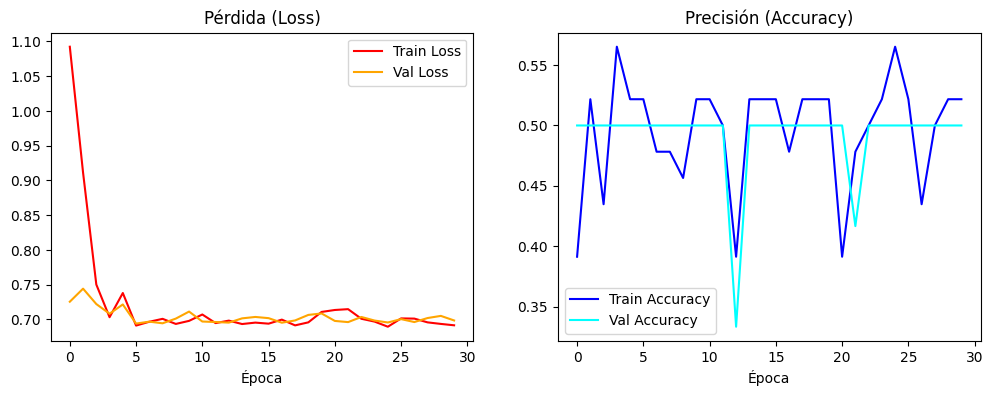

In [19]:
# Detectar automáticamente la forma de los datos (debería ser 40, 44)
forma_entrada = (X_train.shape[1], X_train.shape[2])

# Hiperparámetros a probar (La rúbrica pide experimentar con estos)
capas_ocultas = 2
neuronas = 64

print(f"Creando modelo con {capas_ocultas} capas ocultas de {neuronas} neuronas...")
modelo_luz = create_model(num_hidden_layers=capas_ocultas, neurons_per_layer=neuronas, input_shape=forma_entrada)

print("Iniciando entrenamiento...\n")
# Entrenamos por 30 épocas
historia = modelo_luz.fit(X_train, y_train,
                          epochs=30,
                          batch_size=8,
                          validation_data=(X_test, y_test),
                          verbose=1) # verbose=1 muestra la barrita de progreso

print("\nGráficas de rendimiento...")
plot_history(historia)

<a id='fase4'></a>
## Fase 4: Evaluación y Resultados

### Paso 4.1: Simulación de salida
Implementamos la lógica para interpretar la predicción del modelo.

In [20]:
def interpret_prediction(prediction):
    if prediction > 0.5:
        return "Luz Encendida"
    else:
        return "Luz Apagada"

prob = modelo_luz.predict(X_test[0:1])
print(f"Probabilidad arrojada por la red: {prob[0][0]:.4f}")
print(f"Resultado interpretado: {interpret_prediction(prob[0][0])}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Probabilidad arrojada por la red: 0.4770
Resultado interpretado: Luz Apagada


### Paso 4.2: Prueba ciega (voz del profesor)
Cargaremos un audio externo, aplicaremos el mismo preprocesamiento y evaluaremos el resultado para ver si el modelo generaliza correctamente.

In [22]:
def predict_audio(file_path, model):
    # 1. Aplicar el mismo preprocesamiento
    features = extract_features(file_path)
    if features is not None:
        # Añadir la dimensión del batch
        features = np.expand_dims(features, axis=0)
        # 2. Predecir
        prediction = model.predict(features)
        # 3. Interpretar
        result = interpret_prediction(prediction[0][0])
        print(f"Predicción para el audio '{file_path}':")
        print(f" -> {result} (Probabilidad de encendido: {prediction[0][0]:.4f})")
    else:
        print("No se pudo procesar el audio para la predicción.")

path_audio_profesor = '/content/drive/MyDrive/Librosa/encenderluz/Encender_179169.wav'
predict_audio(path_audio_profesor, modelo_luz)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicción para el audio '/content/drive/MyDrive/Librosa/encenderluz/Encender_179169.wav':
 -> Luz Apagada (Probabilidad de encendido: 0.4874)


<a id='conclusiones'></a>
## Conclusiones
